<a href="https://colab.research.google.com/github/LixiJiang/CIS5450Final/blob/lixi/CIS5450_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1 Data Cleaning**
### *Dataset and Cleaning Objective*

The original dataset can be found & downloaded using this link: https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system

The dataset used in this project is the CDC Behavioral Risk Factor Surveillance System (BRFSS). BRFSS a large-scale health survey that collects information on health behaviors, chronic conditions, and demographic characteristics across the United States. It includes variables such as physical activity, diet, BMI, smoking, alcohol use, and general health, which are relevant to diabetes risk.

However, the raw dataset contains complex coding, invalid responses (e.g., "don't know" and "refused"), and many categorical variables that are not directly suitable for analysis.

The objective of the data cleaning process is to transform the dataset into a structured and model-ready format. This includes selecting relevant features, removing invalid entries, standardizing variables, and converting them into binary or ordinal forms.

Finally, the diabetes variable is recoded into a binary outcome, where prediabetes and diabetes are combined into a single high-risk group. This enables the dataset to be used for binary classification and predictive modeling.

### **1.1 Get Data and Raw Data Overview**

In 1.1, we will first get the data and see what we need to clean to make the data more structured.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cdc/behavioral-risk-factor-surveillance-system")

print("Path to dataset files:", path)

100%|██████████| 414M/414M [00:04<00:00, 90.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/cdc/behavioral-risk-factor-surveillance-system/versions/1


In [2]:
#imports
import os
import pandas as pd
import numpy as np
import random
random.seed(1)

In [3]:
#get the data
year = '2015'
file_path = os.path.join(path, f"{year}.csv")
df = pd.read_csv(file_path)

In [4]:
# configure pandas display options
pd.set_option('display.max_columns', None)

# quick overview of dataset structure and data types
df.info()

# preview data to ensure correct loading
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441456 entries, 0 to 441455
Columns: 330 entries, _STATE to _AIDTST3
dtypes: float64(323), object(7)
memory usage: 1.1+ GB


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,PVTRESD1,COLGHOUS,STATERES,CELLFON3,LADULT,NUMADULT,NUMMEN,NUMWOMEN,CTELNUM1,CELLFON2,CADULT,PVTRESD2,CCLGHOUS,CSTATE,LANDLINE,HHADULT,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,HLTHPLN1,PERSDOC2,MEDCOST,CHECKUP1,BPHIGH4,BPMEDS,BLOODCHO,CHOLCHK,TOLDHI2,CVDINFR4,CVDCRHD4,CVDSTRK3,ASTHMA3,ASTHNOW,CHCSCNCR,CHCOCNCR,CHCCOPD1,HAVARTH3,ADDEPEV2,CHCKIDNY,DIABETE3,DIABAGE2,SEX,MARITAL,EDUCA,RENTHOM1,NUMHHOL2,NUMPHON2,CPDEMO1,VETERAN3,EMPLOY1,CHILDREN,INCOME2,INTERNET,WEIGHT2,HEIGHT3,PREGNANT,QLACTLM2,USEEQUIP,BLIND,DECIDE,DIFFWALK,DIFFDRES,DIFFALON,SMOKE100,SMOKDAY2,STOPSMK2,LASTSMK2,USENOW3,ALCDAY5,AVEDRNK2,DRNK3GE5,MAXDRNKS,FRUITJU1,FRUIT1,FVBEANS,FVGREEN,FVORANG,VEGETAB1,EXERANY2,EXRACT11,EXEROFT1,EXERHMM1,EXRACT21,EXEROFT2,EXERHMM2,STRENGTH,LMTJOIN3,ARTHDIS2,ARTHSOCL,JOINPAIN,SEATBELT,FLUSHOT6,FLSHTMY2,IMFVPLAC,PNEUVAC3,HIVTST6,HIVTSTD3,WHRTST10,PDIABTST,PREDIAB1,INSULIN,BLDSUGAR,FEETCHK2,DOCTDIAB,CHKHEMO3,FEETCHK,EYEEXAM,DIABEYE,DIABEDU,PAINACT2,QLMENTL2,QLSTRES2,QLHLTH2,CAREGIV1,CRGVREL1,CRGVLNG1,CRGVHRS1,CRGVPRB1,CRGVPERS,CRGVHOUS,CRGVMST2,CRGVEXPT,VIDFCLT2,VIREDIF3,VIPRFVS2,VINOCRE2,VIEYEXM2,VIINSUR2,VICTRCT4,VIGLUMA2,VIMACDG2,CIMEMLOS,CDHOUSE,CDASSIST,CDHELP,CDSOCIAL,CDDISCUS,WTCHSALT,LONGWTCH,DRADVISE,ASTHMAGE,ASATTACK,ASERVIST,ASDRVIST,ASRCHKUP,ASACTLIM,ASYMPTOM,ASNOSLEP,ASTHMED3,ASINHALR,HAREHAB1,STREHAB1,CVDASPRN,ASPUNSAF,RLIVPAIN,RDUCHART,RDUCSTRK,ARTTODAY,ARTHWGT,ARTHEXER,ARTHEDU,TETANUS,HPVADVC2,HPVADSHT,SHINGLE2,HADMAM,HOWLONG,HADPAP2,LASTPAP2,HPVTEST,HPLSTTST,HADHYST2,PROFEXAM,LENGEXAM,BLDSTOOL,LSTBLDS3,HADSIGM3,HADSGCO1,LASTSIG3,PCPSAAD2,PCPSADI1,PCPSARE1,PSATEST1,PSATIME,PCPSARS1,PCPSADE1,PCDMDECN,SCNTMNY1,SCNTMEL1,SCNTPAID,SCNTWRK1,SCNTLPAD,SCNTLWK1,SXORIENT,TRNSGNDR,RCSGENDR,RCSRLTN2,CASTHDX2,CASTHNO2,EMTSUPRT,LSATISFY,ADPLEASR,ADDOWN,ADSLEEP,ADENERGY,ADEAT1,ADFAIL,ADTHINK,ADMOVE,MISTMNT,ADANXEV,QSTVER,QSTLANG,EXACTOT1,EXACTOT2,MSCODE,_STSTR,_STRWT,_RAWRAKE,_WT2RAKE,_CHISPNC,_CRACE1,_CPRACE,_CLLCPWT,_DUALUSE,_DUALCOR,_LLCPWT,_RFHLTH,_HCVU651,_RFHYPE5,_CHOLCHK,_RFCHOL,_MICHD,_LTASTH1,_CASTHM1,_ASTHMS1,_DRDXAR1,_PRACE1,_MRACE1,_HISPANC,_RACE,_RACEG21,_RACEGR3,_RACE_G1,_AGEG5YR,_AGE65YR,_AGE80,_AGE_G,HTIN4,HTM4,WTKG3,_BMI5,_BMI5CAT,_RFBMI5,_CHLDCNT,_EDUCAG,_INCOMG,_SMOKER3,_RFSMOK3,DRNKANY5,DROCDY3_,_RFBING5,_DRNKWEK,_RFDRHV5,FTJUDA1_,FRUTDA1_,BEANDAY_,GRENDAY_,ORNGDAY_,VEGEDA1_,_MISFRTN,_MISVEGN,_FRTRESP,_VEGRESP,_FRUTSUM,_VEGESUM,_FRTLT1,_VEGLT1,_FRT16,_VEG23,_FRUITEX,_VEGETEX,_TOTINDA,METVL11_,METVL21_,MAXVO2_,FC60_,ACTIN11_,ACTIN21_,PADUR1_,PADUR2_,PAFREQ1_,PAFREQ2_,_MINAC11,_MINAC21,STRFREQ_,PAMISS1_,PAMIN11_,PAMIN21_,PA1MIN_,PAVIG11_,PAVIG21_,PA1VIGM_,_PACAT1,_PAINDX1,_PA150R2,_PA300R2,_PA30021,_PASTRNG,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,1.0,NaN,1.0,2.0,NaN,3.0,1.000000e+00,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,15.0,18.0,10.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,3.0,NaN,2.0,1.0,4.0,1.0,2.0,NaN,1.0,2.0,8.0,88.0,3.0,2.0,280.0,510.0,NaN,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,NaN,2.0,3.0,888.0,NaN,NaN,NaN,305.0,310.0,320.0,310.0,305.0,101.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,888.0,1.0,1.0,1.0,6.0,1.0,1.0,112014.0,1.0,1.0,1.0,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b'',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,b'',b'',3.0,11011.0,28.78156,3.0,86.344681,NaN,NaN,NaN,NaN,1.0,0.614125,341.384853,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,9.0,1.0,63.0,5.0,70.0,178.0,12701.0,4018.0,4.0,2.0,1.0,2.0

## **1.2 Data Cleaning**

In this part, we will first find relevant features for our modeling and hypothesis tests. Then we will interpret the answer in the dataset according to https://www.cdc.gov/brfss/annual_data/2015/pdf/codebook15_llcp.pdf (e.g. In TOLDHI2 column, the question is: Have you EVER been told by a doctor, nurse or other health professional that your blood cholesterol is high? The answer is shown as numbers in the dataset: 0 = no, 1 = yes, 7 = don't know, 9 = refused. We will remove the "don't know" and "refused" answers to get cleaned data.)

In [5]:
# define list of relevant features
selected_cols = [
    'DIABETE3', '_RFHYPE5', 'TOLDHI2', '_CHOLCHK',
    '_BMI5', 'SMOKE100',
    'CVDSTRK3', '_MICHD',
    '_TOTINDA',
    '_FRTLT1', '_VEGLT1',
    '_RFDRHV5',
    'HLTHPLN1', 'MEDCOST',
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'DIFFWALK',
    'SEX', '_AGEG5YR', 'EDUCA', 'INCOME2'
]

# keep only columns that matters
existing_cols = [col for col in selected_cols if col in df.columns]

# create a new dataframe with selected features
df_selected = df.loc[:, existing_cols].copy()

# check result
print("Selected shape:", df_selected.shape)
df_selected.head()

Selected shape: (441456, 22)


,DIABETE3,_RFHYPE5,TOLDHI2,_CHOLCHK,_BMI5,SMOKE100,CVDSTRK3,_MICHD,_TOTINDA,_FRTLT1,_VEGLT1,_RFDRHV5,HLTHPLN1,MEDCOST,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,SEX,_AGEG5YR,EDUCA,INCOME2
0,3.0,2.0,1.0,1.0,4018.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,5.0,18.0,15.0,1.0,2.0,9.0,4.0,3.0
1,3.0,1.0,2.0,2.0,2509.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,3.0,88.0,88.0,2.0,2.0,7.0,6.0,1.0
2,3.0,1.0,1.0,1.0,2204.0,NaN,1.0,NaN,9.0,9.0,9.0,9.0,1.0,2.0,4.0,88.0,15.0,NaN,2.0,11.0,4.0,99.0
3,3.0,2.0,1.0,1.0,2819.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,5.0,30.0,30.0,1.0,2.0,9.0,4.0,8.0
4,3.0,1.0,2.0,1.0,2437.0,2.0,2.0,2.0,2.0,9.0,1.0,1.0,1.0,2.0,5.0,88.0,20.0,2.0,2.0,9.0,5.0,77.0


In [6]:
# remove rows with any missing values
df_selected = df_selected.loc[df_selected.notna().all(axis=1)].copy()

In [7]:
# clean and recode DIABETE3 variable
# Reference for the questions and answers for each column: https://www.cdc.gov/brfss/annual_data/2015/pdf/codebook15_llcp.pdf

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected[~df_selected["DIABETE3"].isin([7, 9])].copy()

# map original categories to ordinal values
mapping = {
    1: 2,  # diabetes
    2: 0,  # no diabetes
    3: 0,  # no diabetes
    4: 1   # pre-diabetes
}

df_selected["DIABETE3"] = df_selected["DIABETE3"].map(mapping)

# verify unique values after transformation
print("DIABETE3 unique values:", df_selected["DIABETE3"].unique())

DIABETE3 unique values: [0 2 1]


In [8]:
# clean and recode high blood pressure variable (_RFHYPE5)

# remove invalid responses (9 = refused)
df_selected = df_selected.loc[~df_selected["_RFHYPE5"].isin([9])].copy()

# convert to binary: 0 = no, 1 = yes
df_selected["_RFHYPE5"] = df_selected["_RFHYPE5"].map({
    1: 0,  # no high blood pressure
    2: 1   # high blood pressure
})

# verify transformation
print("_RFHYPE5 unique values:", df_selected["_RFHYPE5"].unique())

_RFHYPE5 unique values: [1 0]


In [9]:
# clean and recode cholesterol awareness variable (TOLDHI2)

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["TOLDHI2"].isin([7, 9])].copy()

# convert to binary: 0 = no, 1 = yes
df_selected["TOLDHI2"] = df_selected["TOLDHI2"].map({
    1: 1,  # told high cholesterol
    2: 0   # not told
})

# verify result
print("TOLDHI2 unique values:", df_selected["TOLDHI2"].unique())

TOLDHI2 unique values: [1 0]


In [10]:
# clean and recode cholesterol check variable (_CHOLCHK)

# remove invalid responses (9 = refused)
df_selected = df_selected.loc[~df_selected["_CHOLCHK"].isin([9])].copy()

# convert to binary: 1 = checked within 5 years, 0 = not checked
df_selected["_CHOLCHK"] = df_selected["_CHOLCHK"].map({
    1: 1,  # checked
    2: 0,  # not checked
    3: 0   # not checked
})

# verify result
print("_CHOLCHK unique values:", df_selected["_CHOLCHK"].unique())

_CHOLCHK unique values: [1 0]


In [11]:
# convert BMI values from scaled integers to standard BMI units
df_selected["_BMI5"] = (df_selected["_BMI5"] / 100).round(2)

# inspect transformed BMI values
print("Sample BMI values:", df_selected["_BMI5"].unique()[:10])

Sample BMI values: [40.18 25.09 28.19 24.37 26.52 23.89 25.22 30.04 25.75 22.6 ]


In [12]:
# remove invalid responses for smoking history
df_selected = df_selected.loc[~df_selected["SMOKE100"].isin([7, 9])].copy()

# recode smoking history as a binary variable
df_selected["SMOKE100"] = df_selected["SMOKE100"].map({
    1: 1,  # yes
    2: 0   # no
})

# verify the recoding result
print("SMOKE100 unique values:", df_selected["SMOKE100"].unique())

SMOKE100 unique values: [1 0]


In [13]:
# clean and recode stroke history variable (CVDSTRK3)

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["CVDSTRK3"].isin([7, 9])].copy()

# convert to binary: 0 = no stroke, 1 = had stroke
df_selected["CVDSTRK3"] = df_selected["CVDSTRK3"].map({
    1: 1,  # yes (had stroke)
    2: 0   # no
})

# verify transformation
print("CVDSTRK3 unique values:", df_selected["CVDSTRK3"].unique())

CVDSTRK3 unique values: [0 1]


In [14]:
# recode heart disease variable (_MICHD)

# convert to binary: 0 = no MI/CHD, 1 = yes
df_selected["_MICHD"] = df_selected["_MICHD"].map({
    1: 1,  # has MI or CHD
    2: 0   # no
})

# verify transformation
print("_MICHD unique values:", df_selected["_MICHD"].unique())

_MICHD unique values: [0 1]


In [15]:
# clean and recode physical activity variable (_TOTINDA)

# remove invalid responses (9 = don't know / refused)
df_selected = df_selected.loc[~df_selected["_TOTINDA"].isin([9])].copy()

# convert to binary: 1 = physically active, 0 = not active
df_selected["_TOTINDA"] = df_selected["_TOTINDA"].map({
    1: 1,  # active
    2: 0   # inactive
})

# verify transformation
print("_TOTINDA unique values:", df_selected["_TOTINDA"].unique())

_TOTINDA unique values: [0 1]


In [16]:
# clean and recode fruit consumption variable (_FRTLT1)

# remove invalid responses (9 = missing/refused)
df_selected = df_selected.loc[~df_selected["_FRTLT1"].isin([9])].copy()

# convert to binary: 1 = consumes fruit daily, 0 = does not
df_selected["_FRTLT1"] = df_selected["_FRTLT1"].map({
    1: 1,  # consumes fruit
    2: 0   # does not consume
})

# verify transformation
print("_FRTLT1 unique values:", df_selected["_FRTLT1"].unique())

_FRTLT1 unique values: [0 1]


In [17]:
# clean and recode vegetable consumption variable (_VEGLT1)

# filter out invalid responses (9 = missing/refused)
df_selected = df_selected.loc[~df_selected["_VEGLT1"].isin([9])].copy()

# convert to binary: 1 = consumes vegetables, 0 = does not
df_selected["_VEGLT1"] = df_selected["_VEGLT1"].map({
    1: 1,  # consumes vegetables
    2: 0   # does not consume
})

# verify transformation
print("_VEGLT1 unique values:", df_selected["_VEGLT1"].unique())

_VEGLT1 unique values: [1 0]


In [18]:
# clean and recode heavy drinking variable (_RFDRHV5)

# remove invalid responses (9 = missing/refused)
df_selected = df_selected.loc[~df_selected["_RFDRHV5"].isin([9])].copy()

# convert to binary: 1 = heavy drinking, 0 = not heavy drinking
df_selected["_RFDRHV5"] = df_selected["_RFDRHV5"].map({
    1: 0,  # no heavy drinking
    2: 1   # heavy drinking
})

# verify transformation
print("_RFDRHV5 unique values:", df_selected["_RFDRHV5"].unique())

_RFDRHV5 unique values: [0 1]


In [19]:
# clean and recode healthcare coverage variable (HLTHPLN1)

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["HLTHPLN1"].isin([7, 9])].copy()

# convert to binary: 1 = has healthcare coverage, 0 = no coverage
df_selected["HLTHPLN1"] = df_selected["HLTHPLN1"].map({
    1: 1,  # has coverage
    2: 0   # no coverage
})

# verify transformation
print("HLTHPLN1 unique values:", df_selected["HLTHPLN1"].unique())

HLTHPLN1 unique values: [1 0]


In [20]:
# clean and recode cost barrier variable (MEDCOST)

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["MEDCOST"].isin([7, 9])].copy()

# convert to binary: 1 = could not afford care, 0 = no cost barrier
df_selected["MEDCOST"] = df_selected["MEDCOST"].map({
    1: 1,  # yes (cost prevented care)
    2: 0   # no
})

# verify transformation
print("MEDCOST unique values:", df_selected["MEDCOST"].unique())

MEDCOST unique values: [0 1]


In [21]:
# clean general health rating variable (GENHLTH)

# exclude invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["GENHLTH"].isin([7, 9])].copy()

# keep GENHLTH as an ordinal variable:
# 1 = excellent, 5 = poor
print("GENHLTH unique values:", sorted(df_selected["GENHLTH"].unique()))

GENHLTH unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [22]:
# clean mental health days variable (MENTHLTH)

# recode 88 as 0 because it represents zero bad mental health days
df_selected["MENTHLTH"] = df_selected["MENTHLTH"].replace(88, 0)

# remove invalid responses (77 = don't know, 99 = refused)
df_selected = df_selected.loc[~df_selected["MENTHLTH"].isin([77, 99])].copy()

# confirm remaining values are within the valid 0-30 range
print("MENTHLTH unique values:", sorted(df_selected["MENTHLTH"].unique()))

MENTHLTH unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0)]


In [23]:
# clean physical health days variable (PHYSHLTH)

# recode 88 as 0 (no physically unhealthy days)
df_selected["PHYSHLTH"] = df_selected["PHYSHLTH"].replace(88, 0)

# remove invalid responses (77 = don't know, 99 = refused)
df_selected = df_selected.loc[~df_selected["PHYSHLTH"].isin([77, 99])].copy()

# verify values fall within expected range (0–30 days)
print("PHYSHLTH unique values:", sorted(df_selected["PHYSHLTH"].unique()))

PHYSHLTH unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0)]


In [24]:
# clean and recode difficulty walking variable (DIFFWALK)

# remove invalid responses (7 = don't know, 9 = refused)
df_selected = df_selected.loc[~df_selected["DIFFWALK"].isin([7, 9])].copy()

# convert to binary: 1 = has difficulty walking, 0 = no difficulty
df_selected["DIFFWALK"] = df_selected["DIFFWALK"].map({
    1: 1,  # yes
    2: 0   # no
})

# verify transformation
print("DIFFWALK unique values:", df_selected["DIFFWALK"].unique())

DIFFWALK unique values: [1 0]


In [25]:
# recode gender variable (SEX)

# convert to binary: 1 = male, 0 = female
df_selected["SEX"] = df_selected["SEX"].map({
    1: 1,  # male
    2: 0   # female
})

# verify transformation
print("SEX unique values:", df_selected["SEX"].unique())

SEX unique values: [0 1]


In [26]:
# clean age group variable (_AGEG5YR)

# remove invalid category (14 = missing/don't know)
df_selected = df_selected.loc[df_selected["_AGEG5YR"] != 14].copy()

# keep as ordinal variable (1 = youngest group, 13 = oldest group)
print("_AGEG5YR unique values:", sorted(df_selected["_AGEG5YR"].unique()))

_AGEG5YR unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0)]


In [27]:
# clean education level variable (EDUCA)

# remove invalid response code (9 = refused)
df_selected = df_selected.loc[df_selected["EDUCA"] != 9].copy()

# keep EDUCA as an ordinal variable:
# 1 = lowest education level, 6 = highest education level
print("EDUCA unique values:", sorted(df_selected["EDUCA"].unique()))

EDUCA unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


In [28]:
# clean income category variable (INCOME2)

# exclude invalid responses (77 = don't know, 99 = refused)
df_selected = df_selected.loc[~df_selected["INCOME2"].isin([77, 99])].copy()

# keep INCOME2 as an ordinal variable:
# lower values indicate lower income categories
print("INCOME2 unique values:", sorted(df_selected["INCOME2"].unique()))

INCOME2 unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]


In [29]:
df_selected.shape
df_selected.head(10)

,DIABETE3,_RFHYPE5,TOLDHI2,_CHOLCHK,_BMI5,SMOKE100,CVDSTRK3,_MICHD,_TOTINDA,_FRTLT1,_VEGLT1,_RFDRHV5,HLTHPLN1,MEDCOST,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,SEX,_AGEG5YR,EDUCA,INCOME2
0,0,1,1,1,40.18,1,0,0,0,0,1,0,1,0,5.0,18.0,15.0,1,0,9.0,4.0,3.0
1,0,0,0,0,25.09,1,0,0,1,0,0,0,0,1,3.0,0.0,0.0,0,0,7.0,6.0,1.0
3,0,1,1,1,28.19,0,0,0,0,1,0,0,1,1,5.0,30.0,30.0,1,0,9.0,4.0,8.0
5,0,1,0,1,26.52,0,0,0,1,1,1,0,1,0,2.0,0.0,0.0,0,0,11.0,3.0,6.0
6,0,1,1,1,23.89,0,0,0,1,1,1,0,1,0,2.0,3.0,0.0,0,0,11.0,5.0,4.0
9,0,1,1,1,25.22,1,0,0,1,1,1,0,1,0,2.0,0.0,2.0,0,1,10.0,6.0,8.0
10,0,1,0,1,30.04,1,0,0,0,0,0,0,1,0,3.0,0.0,14.0,0,0,9.0,6.0,7.0
15,0,1,1,1,25.00,1,0,0,1,0,1,0,1,0,3.0,0.0,0.0,1,0,11.0,4.0,4.0
16,2,1,1,1,30.41,1,0,1,0,1,1,0,1,0,5.0,30.0,30.0,1,0,9.0,5.0,1.0
19,0,0,0,1,24.07,0,0,0,0,0,1,0,1,0,2.0,0.0,0.0,0,1,8.0,4.0,3.0


## 1.3 Make feature names more readable

We will then convert the ambiguous original name of the columns into words that we can actually understand, and save a copy as our final cleaned dataset.

In [30]:
# create a mapping dictionary for renaming columns
rename_dict = {
    "DIABETE3": "Diabetes",
    "_RFHYPE5": "HighBP",
    "TOLDHI2": "HighChol",
    "_CHOLCHK": "CholCheck",
    "_BMI5": "BMI",
    "SMOKE100": "Smoker",
    "CVDSTRK3": "Stroke",
    "_MICHD": "HeartDisease",
    "_TOTINDA": "PhysActivity",
    "_FRTLT1": "Fruit",
    "_VEGLT1": "Veggie",
    "_RFDRHV5": "HeavyAlcohol",
    "HLTHPLN1": "Healthcare",
    "MEDCOST": "CostBarrier",
    "GENHLTH": "GenHealth",
    "MENTHLTH": "MentHealth",
    "PHYSHLTH": "PhysHealth",
    "DIFFWALK": "DiffWalk",
    "SEX": "Sex",
    "_AGEG5YR": "AgeGroup",
    "EDUCA": "Education",
    "INCOME2": "Income"
}

# apply renaming
df_final = df_selected.rename(columns=rename_dict)

# preview renamed dataset
df_final.head()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease,PhysActivity,Fruit,Veggie,HeavyAlcohol,Healthcare,CostBarrier,GenHealth,MentHealth,PhysHealth,DiffWalk,Sex,AgeGroup,Education,Income
0,0,1,1,1,40.18,1,0,0,0,0,1,0,1,0,5.0,18.0,15.0,1,0,9.0,4.0,3.0
1,0,0,0,0,25.09,1,0,0,1,0,0,0,0,1,3.0,0.0,0.0,0,0,7.0,6.0,1.0
3,0,1,1,1,28.19,0,0,0,0,1,0,0,1,1,5.0,30.0,30.0,1,0,9.0,4.0,8.0
5,0,1,0,1,26.52,0,0,0,1,1,1,0,1,0,2.0,0.0,0.0,0,0,11.0,3.0,6.0
6,0,1,1,1,23.89,0,0,0,1,1,1,0,1,0,2.0,3.0,0.0,0,0,11.0,5.0,4.0


In [31]:
df_final.shape

(253680, 22)

In [32]:
#save cleaned data to csv
df_final.to_csv('diabetes_health_indicators_BRFSS2015.csv', sep=",", index=False)

## **1.4 Create Binary Dataset**

In the "Diabetes" column, there are three categories: no diabetes, prediabetes, and diabetes. Since our goal is to identify the factors associated with diabetes risk, we convert this variable into a binary outcome.

Specifically, individuals with prediabetes and diagnosed diabetes are grouped together as a single positive class, while individuals without diabetes form the negative class. This transformation simplifies the problem into a binary classification task, which is more suitable for many machine learning models.

This grouping is also medically reasonable. Prediabetes represents an intermediate and high-risk state, where individuals have elevated blood glucose levels and a significantly higher likelihood of developing diabetes in the future. Therefore, combining prediabetes with diabetes allows us to focus on identifying individuals at risk, rather than only those who have already been diagnosed.

In [33]:
# create a copy for binary classification
df_binary = df_final.copy()

# convert the target variable to binary:
# 0 = no diabetes
# 1 = prediabetes or diabetes
df_binary["Diabetes"] = df_binary["Diabetes"].map({
    0: 0,
    1: 1,
    2: 1
})

# check the result
print("Unique target values:", sorted(df_binary["Diabetes"].unique()))
print(df_binary["Diabetes"].value_counts())
df_binary.head()

Unique target values: [np.int64(0), np.int64(1)]
Diabetes
0    213703
1     39977
Name: count, dtype: int64


,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease,PhysActivity,Fruit,Veggie,HeavyAlcohol,Healthcare,CostBarrier,GenHealth,MentHealth,PhysHealth,DiffWalk,Sex,AgeGroup,Education,Income
0,0,1,1,1,40.18,1,0,0,0,0,1,0,1,0,5.0,18.0,15.0,1,0,9.0,4.0,3.0
1,0,0,0,0,25.09,1,0,0,1,0,0,0,0,1,3.0,0.0,0.0,0,0,7.0,6.0,1.0
3,0,1,1,1,28.19,0,0,0,0,1,0,0,1,1,5.0,30.0,30.0,1,0,9.0,4.0,8.0
5,0,1,0,1,26.52,0,0,0,1,1,1,0,1,0,2.0,0.0,0.0,0,0,11.0,3.0,6.0
6,0,1,1,1,23.89,0,0,0,1,1,1,0,1,0,2.0,3.0,0.0,0,0,11.0,5.0,4.0


## **1.5 Dataset Visualization**

In this section, we conduct exploratory data analysis (EDA) through a series of visualizations to better understand the structure of the dataset and the relationships between features and diabetes outcomes. The goal of this analysis is not only to summarize the data, but also to extract meaningful patterns that can inform our modeling decisions.

We focus on visualizing key demographic, health, and lifestyle variables, and compare their distributions across individuals with and without diabetes. These visualizations help identify important predictors (e.g., BMI, age, and health conditions), reveal potential class imbalance, and highlight correlations among features.



In [34]:
# import
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# copy dataset to avoid modifying original
df = df_binary.copy()

# separate groups for convenience
df_diab = df[df["Diabetes"] == 1]
df_no_diab = df[df["Diabetes"] == 0]

### **1.5.1 Diabetes Distribution (Class Balance)**
This visualization shows the distribution of the target variable, Diabetes, in the dataset. The majority of individuals fall into the non-diabetic group (0), accounting for approximately 84% of the data, while about 16% are classified as having diabetes or prediabetes (1).

This indicates a clear class imbalance in the dataset. Such imbalance can bias models toward predicting the majority class, leading to misleadingly high accuracy but poor performance in identifying high-risk individuals.

As a result, this insight informs our modeling approach: we will place greater emphasis on evaluation metrics such as precision, recall, and F1-score, rather than accuracy alone. Additionally, techniques such as class weighting or resampling may be considered to address this imbalance.

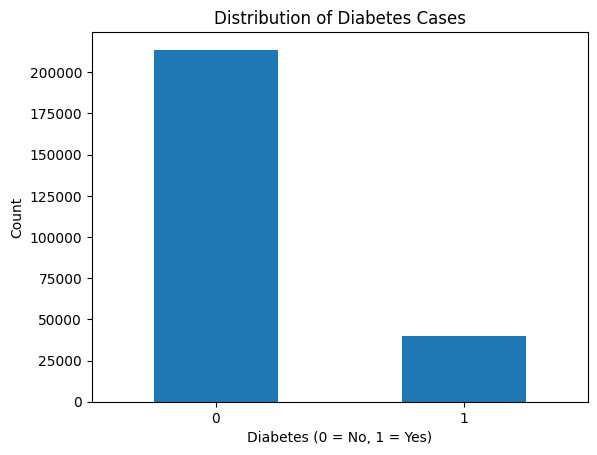

Class distribution:
 Diabetes
0    0.842412
1    0.157588
Name: count, dtype: float64


In [35]:
counts = df["Diabetes"].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Class distribution:\n", counts / len(df))

### **1.5.2 BMI vs Diabetes (Key Risk Factor)**
Here we compare the distribution of Body Mass Index (BMI) between individuals with and without diabetes. BMI is a key health indicator and is widely associated with metabolic conditions such as diabetes.

From the plot, we observe that the BMI distribution for individuals with diabetes is shifted to the right compared to those without diabetes. This indicates that higher BMI values are more prevalent among individuals in the diabetic group. In contrast, the non-diabetic group is more concentrated in the lower BMI range.

Although there is some overlap between the two distributions, the overall shift suggests a positive relationship between BMI and diabetes risk. This implies that BMI is likely to be an important predictive feature in our model. Additionally, the overlap indicates that BMI alone is not sufficient for prediction, reinforcing the need to incorporate multiple features in the modeling process.

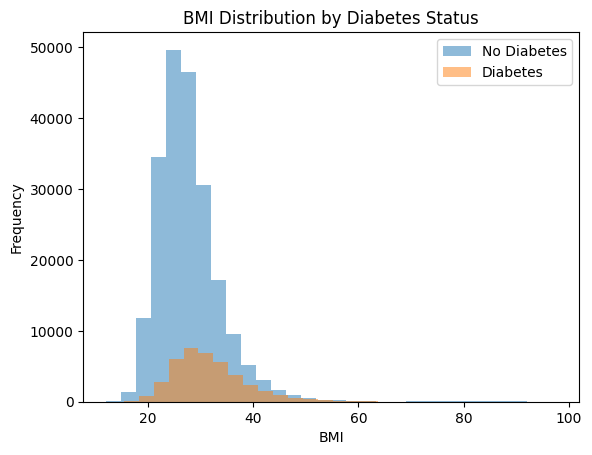

In [36]:
plt.figure()
plt.hist(df_no_diab["BMI"], bins=30, alpha=0.5, label="No Diabetes")
plt.hist(df_diab["BMI"], bins=30, alpha=0.5, label="Diabetes")
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### **1.5.3 Age Group, Income, and Education vs Diabetes Rate**

These visualizations show how the proportion of individuals with diabetes varies across age group, income level, and education level. Age is represented as an ordinal category, with higher values corresponding to older age groups. Income and education are also coded ordinally, with higher values indicating higher socioeconomic status.

The age plot reveals a clear upward trend in diabetes rate as age increases. Younger age groups have very low diabetes prevalence, while the rate rises steadily through middle-aged groups and reaches its highest levels among older individuals. There is a slight decline in the oldest age group, which may be due to a smaller sample size or survivorship effects.

The income plot shows an overall downward trend, with diabetes prevalence generally decreasing as income level increases. Individuals in lower income groups have noticeably higher diabetes rates, while those in higher income groups tend to have lower prevalence. Although the decline is not perfectly monotonic at every level, the overall pattern suggests that lower income is associated with greater diabetes risk.

A similar pattern appears in the education plot. Diabetes prevalence generally decreases as education level increases, indicating that individuals with lower educational attainment face higher diabetes risk. As with income, there are small fluctuations across adjacent levels, but the overall relationship remains clear.

Together, these patterns indicate that diabetes risk is influenced not only by age, but also by broader socioeconomic factors. Age appears to be a strong positive predictor of diabetes risk, while income and education show negative associations with diabetes prevalence. These findings suggest that all three variables should play an important role in our modeling process.

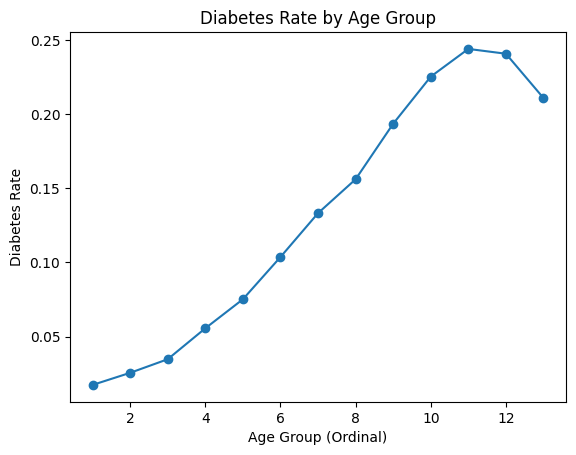

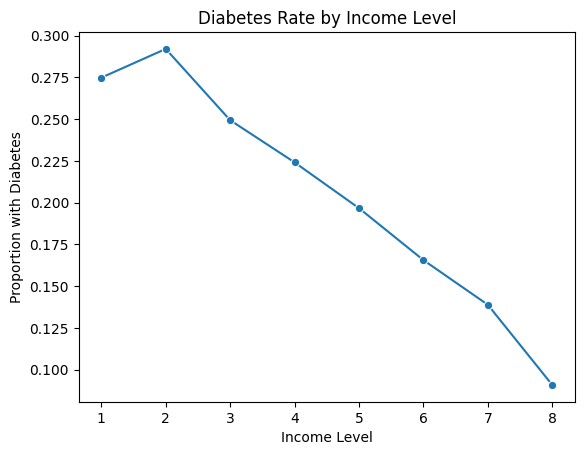

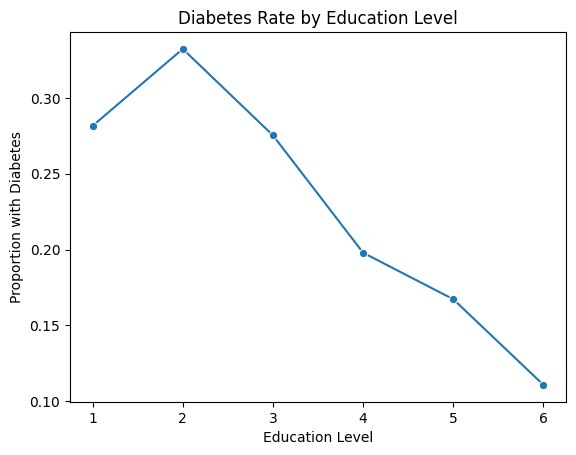

In [70]:
df_eda = df.copy()
age_diabetes_rate = df.groupby("AgeGroup")["Diabetes"].mean()

plt.figure()
age_diabetes_rate.plot(kind='line', marker='o')
plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age Group (Ordinal)")
plt.ylabel("Diabetes Rate")
plt.show()

# Plot diabetes rate by income level
import seaborn as sns
income_rate = df_eda.groupby("Income")["Diabetes"].mean().reset_index()
education_rate = df_eda.groupby("Education")["Diabetes"].mean().reset_index()

plt.figure()
sns.lineplot(data=income_rate, x="Income", y="Diabetes", marker="o")
plt.title("Diabetes Rate by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Proportion with Diabetes")
plt.show()

# Plot diabetes rate by education level
plt.figure()
sns.lineplot(data=education_rate, x="Education", y="Diabetes", marker="o")
plt.title("Diabetes Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Proportion with Diabetes")
plt.show()

### **1.5.4 Health Factors Correlation Heatmap**
This heatmap displays the pairwise correlations between key health, lifestyle, and demographic variables, including their relationships with the target variable, Diabetes. Correlation values range from -1 to 1, where positive values indicate a direct relationship and negative values indicate an inverse relationship.

From the heatmap, we observe that variables such as BMI, HighBP (high blood pressure), HighChol (high cholesterol), and GenHealth show moderate positive correlations with diabetes, suggesting that individuals with poorer physical health and related conditions are more likely to have diabetes. In contrast, variables like PhysActivity tend to show a negative correlation, indicating that higher physical activity is associated with lower diabetes risk.

Additionally, some features (e.g., GenHealth, PhysHealth, and MentHealth) are moderately correlated with each other, which may indicate overlapping information. This suggests potential multicollinearity, particularly for linear models, and highlights the importance of considering feature selection or regularization techniques during modeling.

Overall, this visualization helps identify the most informative features and provides insight into the relationships among variables, guiding both feature engineering and model selection.

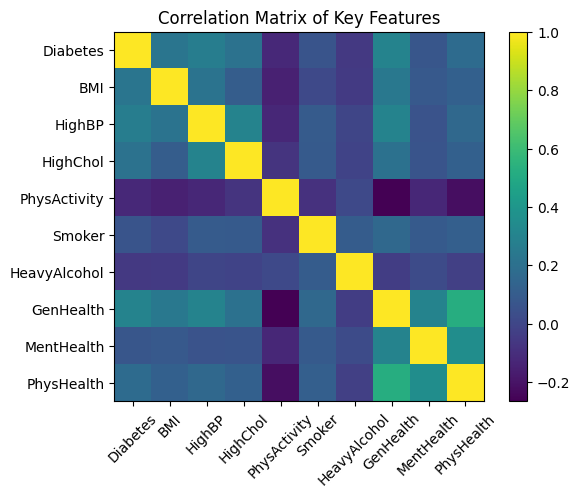

In [38]:
# select subset of key variables
corr_vars = [
    "Diabetes", "BMI", "HighBP", "HighChol",
    "PhysActivity", "Smoker", "HeavyAlcohol",
    "GenHealth", "MentHealth", "PhysHealth"
]

corr_matrix = df[corr_vars].corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_vars)), corr_vars, rotation=45)
plt.yticks(range(len(corr_vars)), corr_vars)

plt.title("Correlation Matrix of Key Features")
plt.show()

### **1.5.5 Lifestyle Factors vs Diabetes (Bar Comparison)**
This visualization compares the proportions of key lifestyle factors between individuals with and without diabetes. These factors include physical activity, smoking, alcohol consumption, and dietary habits (fruit and vegetable intake), which are commonly associated with chronic disease risk.

From the chart, we observe that individuals without diabetes tend to have higher levels of physical activity and slightly healthier dietary habits (higher fruit and vegetable consumption). In contrast, individuals with diabetes show a higher proportion of smoking and lower physical activity levels. Differences in heavy alcohol consumption appear relatively small between the two groups.

These patterns suggest that lifestyle behaviors are associated with diabetes risk, although the differences are not as pronounced as those seen in clinical factors such as BMI or age. This indicates that while lifestyle variables contribute to prediction, they may have weaker individual effects and could be better captured through interaction or nonlinear modeling approaches.

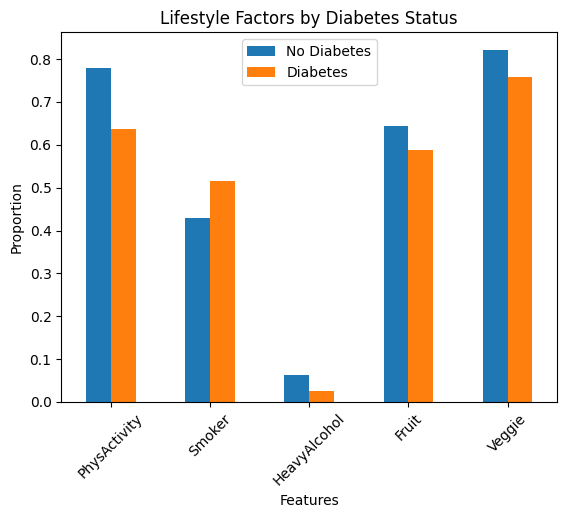

In [39]:
features = ["PhysActivity", "Smoker", "HeavyAlcohol", "Fruit", "Veggie"]

means = df.groupby("Diabetes")[features].mean()

means.T.plot(kind='bar')
plt.title("Lifestyle Factors by Diabetes Status")
plt.xlabel("Features")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(["No Diabetes", "Diabetes"])
plt.show()

### **1.5.6 Variance Inflation Factor (VIF) Analysis**

To formally assess multicollinearity, we compute the Variance Inflation Factor (VIF) for the main predictor variables. Larger VIF values indicate stronger multicollinearity and may lead to unstable Logistic Regression coefficients.

In [40]:
# Select predictors for VIF analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
df_eda = df_binary.copy()
vif_features = [
    "BMI", "HighBP", "HighChol",
    "GenHealth", "PhysActivity",
    "AgeGroup", "Income", "Education"
]

X_vif = df_eda[vif_features].copy()
X_vif_const = add_constant(X_vif)

# Compute VIF values
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif_const.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

display(vif_df)

,Feature,VIF
0,const,78.682782
1,BMI,1.118244
2,HighBP,1.311308
3,HighChol,1.158929
4,GenHealth,1.357018
5,PhysActivity,1.111697
6,AgeGroup,1.209329
7,Income,1.373211
8,Education,1.294494


**Interpretation:**  
The VIF results indicate that multicollinearity is not a major concern for these predictors. All predictor VIF values are close to 1 and below 1.4, which is far below common warning thresholds such as 5 or 10. Although the intercept has a large VIF, this is not a substantive concern. Overall, the selected variables do not appear to have problematic multicollinearity, so Logistic Regression coefficients should remain reasonably stable and interpretable.

### **1.5.7 Visualization Summary**
From the exploratory data analysis, several important patterns emerge:

- BMI and age show strong positive relationships with diabetes risk, indicating that they are likely to be key predictive features.
- Health-related variables such as high blood pressure, high cholesterol, and general health status are moderately correlated with diabetes, suggesting clustering of chronic conditions.
- Lifestyle factors, especially physical activity, show meaningful associations with diabetes. Physically active individuals have a substantially lower diabetes rate than inactive individuals, while other lifestyle variables such as smoking show weaker but still informative patterns.
- Income and education both show overall negative relationships with diabetes prevalence. Individuals with lower income and lower educational attainment tend to have higher diabetes rates, indicating that socioeconomic factors also play an important role in diabetes risk.
- The dataset exhibits class imbalance, with significantly more non-diabetic individuals than diabetic ones. This suggests that model evaluation should rely not only on accuracy, but also on metrics such as precision, recall, F1-score, and ROC-AUC.
- The correlation matrix shows several meaningful associations among predictors, but the VIF analysis indicates that multicollinearity is not a major concern, since all predictor VIF values are low and well below common warning thresholds.

These findings guide our modeling strategy by highlighting important features, supporting the inclusion of both clinical and socioeconomic variables, informing evaluation metric selection, and confirming that Logistic Regression can be used as an interpretable baseline model without severe multicollinearity concerns.

# **2 Modeling**

In this section we build classification models to predict diabetes risk using the cleaned binary dataset `df_binary` produced in Section 1.4. We begin with a **Logistic Regression baseline** that serves as a simple, interpretable reference against which more complex ensemble models (Random Forest, Gradient Boosting) will be compared in later subsections.

## **2.1 Logistic Regression Baseline**

Logistic Regression is chosen as the baseline for three reasons:
1. **Interpretability** — model coefficients directly translate into log-odds contributions of each feature, which supports the project's goal of identifying key diabetes risk factors.
2. **Efficiency** — fits in seconds even on 250k+ rows, so it is cheap to iterate.
3. **Regularization support** — L1 (Lasso) and L2 (Ridge) penalties help control multicollinearity among health indicators (e.g., HighBP, HighChol, BMI).

We train three variants to establish a clear baseline picture:
- **LR (L2, default)** — the textbook baseline.
- **LR (L1)** — sparsity-inducing; also acts as built-in feature selection.
- **LR (L2 + `class_weight='balanced'`)** — addresses the ~84/16 class imbalance by up-weighting the minority class during training.

Evaluation uses 5-fold **Stratified** cross-validation on the training set (ROC-AUC and PR-AUC) plus a held-out 20% test set (accuracy, precision, recall, F1, ROC-AUC, and PR-AUC). Because the dataset is imbalanced, **ROC-AUC, PR-AUC, and minority-class recall/F1 are the primary metrics**, while accuracy alone can be misleading.

### *Step 1 — Imports*

In [41]:
# Modeling imports (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

RANDOM_STATE = 42

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, model, X_train, X_test, y_train, y_test, threshold=0.5):
    """
    Evaluate model with a customizable probability threshold.
    """

    fitted_model = model.fit(X_train, y_train)

    y_prob = fitted_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    print(f"\n===== {name} =====")
    print(f"Threshold used: {threshold}")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print(confusion_matrix(y_test, y_pred))

    return results, fitted_model

In [61]:
model_thresholds = {
    "LR default": 0.3,
    "LR weighted": 0.53,
    "LR SMOTE": 0.53,

    "RF default": 0.2,
    "RF balanced": 0.3,
    "RF balanced_subsample": 0.3,

    "XGB default": 0.3,
    "XGB scale_pos_weight": 0.6
}

### *Step 2 — Feature matrix X and target y*

We separate the 21 predictors from the binary target `Diabetes`. Among the 21 features, 14 are already binary (0/1) and do not need standardization. The remaining 7 are continuous or ordinal and will be standardized inside the pipeline so that L1/L2 regularization treats them on a comparable scale.

In [44]:
# Separate features and target
y = df_binary["Diabetes"].astype(int)
X = df_binary.drop(columns=["Diabetes"]).copy()

# Columns requiring standardization (continuous or ordinal with non-0/1 range)
NUM_COLS = ["BMI", "GenHealth", "MentHealth", "PhysHealth",
            "AgeGroup", "Education", "Income"]

# Sanity check: all expected columns are present
missing = [c for c in NUM_COLS if c not in X.columns]
assert not missing, f"Missing expected numeric columns: {missing}"

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts(normalize=True).round(4)}")
print(f"Numeric (to be scaled) columns: {NUM_COLS}")

X shape: (253680, 21)
y distribution:
Diabetes
0    0.8424
1    0.1576
Name: proportion, dtype: float64
Numeric (to be scaled) columns: ['BMI', 'GenHealth', 'MentHealth', 'PhysHealth', 'AgeGroup', 'Education', 'Income']


### *Step 3 — Stratified train/test split*

An 80/20 split is used. Because the positive class is only ~16% of rows, we stratify on `y` so that the train and test sets preserve this ratio.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}, positives = {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}, positives = {y_test.mean():.4f}")

Train: (202944, 21), positives = 0.1576
Test:  (50736, 21), positives = 0.1576


### *Step 4 — Pipeline: ColumnTransformer + LogisticRegression*

We wrap the preprocessing and the estimator in a single `Pipeline`. The `ColumnTransformer` standardizes only the 7 numeric/ordinal columns and passes the 14 binary columns through untouched. Fitting the scaler inside the pipeline prevents leakage from the test set during CV.

In [46]:
def build_lr_pipeline(penalty="l2", C=1.0, class_weight=None):
    """Return a fresh Pipeline: [StandardScaler on NUM_COLS] -> LogisticRegression."""
    preprocessor = ColumnTransformer(
        transformers=[("num", StandardScaler(), NUM_COLS)],
        remainder="passthrough",
    )
    lr = LogisticRegression(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        solver="liblinear",   # supports both L1 and L2
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    return Pipeline([("prep", preprocessor), ("lr", lr)])

# Quick smoke test: pipeline fits without error
_smoke = build_lr_pipeline().fit(X_train.head(1000), y_train.head(1000))
print("Pipeline builds OK:", _smoke)

Pipeline builds OK: Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['BMI', 'GenHealth',
                                                   'MentHealth', 'PhysHealth',
                                                   'AgeGroup', 'Education',
                                                   'Income'])])),
                ('lr',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])


### *Step 5 — Train variants, 5-fold Stratified CV, and test evaluation*

For each variant we report:
- **CV ROC-AUC and PR-AUC** (mean ± std across 5 stratified folds on the training set)
- **Test ROC-AUC and PR-AUC**
- **Test accuracy / precision / recall / F1** (with emphasis on class 1, the diabetic/prediabetic group)
- **Confusion matrix** on the test set

In addition to the default and class-weighted models, we also include a **SMOTE-based variant**, where the minority class is oversampled within the training pipeline. This allows us to compare reweighting and resampling strategies for handling class imbalance.

Results are collected into a single summary DataFrame for easy comparison.

In [47]:
import pandas as pd

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def build_lr_pipeline(method="default"):
    preprocessor = ColumnTransformer(
        transformers=[("num", StandardScaler(), NUM_COLS)],
        remainder="passthrough"
    )

    if method == "default":
        lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        return Pipeline([("prep", preprocessor), ("lr", lr)])

    elif method == "weighted":
        lr = LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        )
        return Pipeline([("prep", preprocessor), ("lr", lr)])

    elif method == "smote":
        lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("lr", lr)
        ])

lr_variants = {
    "LR default": build_lr_pipeline("default"),
    "LR weighted": build_lr_pipeline("weighted"),
    "LR SMOTE": build_lr_pipeline("smote")
}

lr_results = []
lr_fitted_models = {}

for name, model in lr_variants.items():
    threshold = model_thresholds.get(name, 0.5)

    result, fitted_model = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        threshold=threshold
    )

    lr_results.append(result)
    lr_fitted_models[name] = fitted_model

lr_summary = pd.DataFrame(lr_results)
lr_summary


===== LR default =====
Threshold used: 0.3
              precision    recall  f1-score   support

           0     0.9019    0.8869    0.8943     42741
           1     0.4446    0.4843    0.4636      7995

    accuracy                         0.8234     50736
   macro avg     0.6733    0.6856    0.6790     50736
weighted avg     0.8298    0.8234    0.8264     50736

[[37905  4836]
 [ 4123  3872]]

===== LR weighted =====
Threshold used: 0.53
              precision    recall  f1-score   support

           0     0.9369    0.7511    0.8338     42741
           1     0.3541    0.7295    0.4768      7995

    accuracy                         0.7477     50736
   macro avg     0.6455    0.7403    0.6553     50736
weighted avg     0.8450    0.7477    0.7775     50736

[[32104 10637]
 [ 2163  5832]]

===== LR SMOTE =====
Threshold used: 0.53
              precision    recall  f1-score   support

           0     0.9354    0.7505    0.8328     42741
           1     0.3515    0.7228    0.473

,model,threshold,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
0,LR default,0.30,0.823419,0.444649,0.484303,0.463629,0.817222,0.434392
1,LR weighted,0.53,0.747714,0.354120,0.729456,0.476782,0.817600,0.432628
2,LR SMOTE,0.53,0.746176,0.351499,0.722827,0.472991,0.815015,0.428040


## **2.2 Random Forest**

Random Forest is an ensemble of decision trees that captures **nonlinear relationships** and **feature interactions** without requiring any distributional assumptions or feature scaling. Compared with Logistic Regression, we expect it to:
- benefit from interactions like `HighBP × BMI` that LR cannot capture unless explicitly engineered,
- be more robust to mildly correlated predictors (a well-known issue across the health indicators here),
- produce reliable feature importances via a **permutation-based approach**, which does not suffer from the cardinality bias of the default impurity importance.

We train three variants to examine the effect of class imbalance handling:
- **RF (default)** — no class weighting.
- **RF (balanced)** — `class_weight='balanced'`, which reweights samples inversely to class frequency during splitting.
- **RF (balanced_subsample)** — `class_weight='balanced_subsample'`, which recomputes class weights for each bootstrap sample and can provide a more stable balancing effect.

Hyperparameters are kept modest (`n_estimators=200`, `max_depth=15`) so this is a baseline RF, not a tuned one. Deeper tuning (grid/random search over depth, min_samples_leaf, max_features) is left as future work.

### *Training and evaluation*

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_variants = {
    "RF default": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "RF balanced": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "RF balanced_subsample": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

rf_results = []
rf_fitted_models = {}

for name, model in rf_variants.items():
    threshold = model_thresholds.get(name, 0.5)

    result, fitted_model = evaluate_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        threshold=threshold
    )

    rf_results.append(result)
    rf_fitted_models[name] = fitted_model

rf_summary = pd.DataFrame(rf_results)
rf_summary.sort_values(by="pr_auc", ascending=False)


===== RF default =====
Threshold used: 0.2
              precision    recall  f1-score   support

           0     0.9334    0.7585    0.8369     42741
           1     0.3550    0.7107    0.4735      7995

    accuracy                         0.7509     50736
   macro avg     0.6442    0.7346    0.6552     50736
weighted avg     0.8423    0.7509    0.7796     50736

[[32417 10324]
 [ 2313  5682]]

===== RF balanced =====
Threshold used: 0.3
              precision    recall  f1-score   support

           0     0.9345    0.7237    0.8157     42741
           1     0.3305    0.7290    0.4548      7995

    accuracy                         0.7246     50736
   macro avg     0.6325    0.7263    0.6352     50736
weighted avg     0.8393    0.7246    0.7589     50736

[[30933 11808]
 [ 2167  5828]]

===== RF balanced_subsample =====
Threshold used: 0.3
              precision    recall  f1-score   support

           0     0.9350    0.7227    0.8152     42741
           1     0.3303    0.73

,model,threshold,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
0,RF default,0.2,0.750926,0.354992,0.710694,0.473480,0.814847,0.447219
1,RF balanced,0.3,0.724555,0.330460,0.728956,0.454762,0.802858,0.415922
2,RF balanced_subsample,0.3,0.724042,0.330320,0.731207,0.455066,0.802634,0.414649


### *Permutation feature importance*

Rather than the default impurity-based importance (which is biased toward high-cardinality features), we use **permutation importance** measured as the **drop in ROC-AUC** when each feature's values are randomly shuffled on a held-out sample. This gives a model-agnostic, unbiased ranking of which features actually contribute to predictive performance.

For computational reasons we evaluate on a stratified 2,000-row subsample of the test set with 5 shuffle repeats per feature.

Best Random Forest model: RF default
Permutation importance sample size: 2000
Class distribution in sample:
Diabetes
0    0.8425
1    0.1575
Name: proportion, dtype: float64


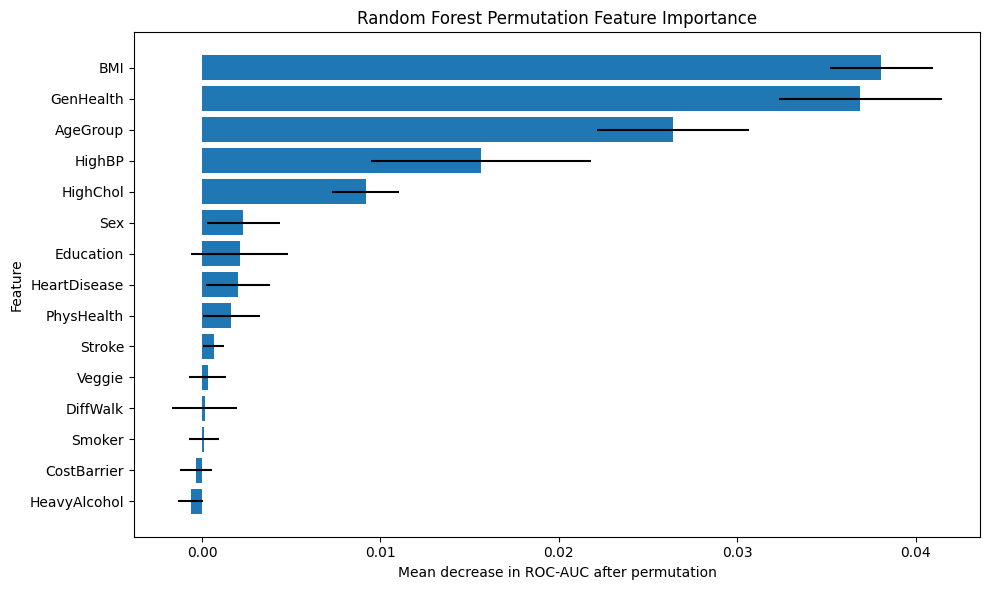

In [49]:
# ---------------------------------------------------------
# Permutation Feature Importance for Random Forest
# ---------------------------------------------------------

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Select the best Random Forest model based on PR-AUC
best_rf_name = rf_summary.sort_values(
    by="pr_auc",
    ascending=False
).iloc[0]["model"]

best_rf_model = rf_variants[best_rf_name]

print("Best Random Forest model:", best_rf_name)

# Refit the selected Random Forest model on the full training set
best_rf_model.fit(X_train, y_train)

# Create a stratified 2,000-row subsample from the test set
# This keeps the class distribution similar to the original test set
sample_size = min(2000, len(X_test))

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test,
    y_test,
    train_size=sample_size,
    stratify=y_test,
    random_state=RANDOM_STATE
)

print("Permutation importance sample size:", len(X_test_sample))
print("Class distribution in sample:")
print(y_test_sample.value_counts(normalize=True))

# Run permutation importance
# The importance score is the mean decrease in ROC-AUC after shuffling each feature
perm_result = permutation_importance(
    best_rf_model,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Create importance table
rf_perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

rf_perm_importance = rf_perm_importance.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

rf_perm_importance.head(15)

# Plot top 15 permutation feature importances

top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    rf_perm_importance.head(top_n)["feature"][::-1],
    rf_perm_importance.head(top_n)["importance_mean"][::-1],
    xerr=rf_perm_importance.head(top_n)["importance_std"][::-1]
)

plt.xlabel("Mean decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Feature Importance")
plt.tight_layout()
plt.show()

## **2.3 Gradient Boosting (XGBoost)**

Gradient boosting builds an ensemble of shallow trees **sequentially**, with each new tree fit to the residuals of the current ensemble. In practice it is one of the strongest off-the-shelf models for structured tabular data, and it is reasonable to expect it to outperform both LR and Random Forest on ROC-AUC here.

Two variants are trained to mirror the LR / RF comparisons:
- **XGB (default)** — no imbalance handling.
- **XGB (scale_pos_weight)** — `scale_pos_weight = n_neg / n_pos`, the standard XGBoost approach for compensating class imbalance by increasing the penalty on misclassified minority-class samples.

**Early stopping** (required by the proposal) is used to pick the number of boosting rounds. We split 15% of the training set as a validation fold, train up to 500 rounds, and stop when the validation AUC has not improved for 20 consecutive rounds. The resulting `best_iteration` is then used as a fixed `n_estimators` for the 5-fold stratified CV and final test evaluation so that CV is comparable across models.

In addition to ROC-AUC, we also report **PR-AUC**, which is more informative under class imbalance. Combined with recall and F1-score for the positive class, this provides a more reliable assessment of the model's ability to identify individuals at risk of diabetes.

### *Training with early stopping*

In [62]:
import xgboost as xgb
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# XGBoost Models
# ---------------------------------------------------------

# Split 15% of X_train as a validation set for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Compute class imbalance ratio for XGBoost
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

print(f"scale_pos_weight (n_neg / n_pos): {scale_pos_weight:.4f}")

xgb_variants = {
    "XGB default": {
        "scale_pos_weight": 1.0
    },
    "XGB scale_pos_weight": {
        "scale_pos_weight": scale_pos_weight
    }
}

xgb_base = {
    "learning_rate": 0.1,
    "max_depth": 6,
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

xgb_results = []
xgb_fitted_models = {}

for name, kwargs in xgb_variants.items():
    print(f"\n===== {name} =====")

    # 1. Use early stopping to choose the best number of trees
    es_clf = xgb.XGBClassifier(
        n_estimators=500,
        early_stopping_rounds=20,
        **xgb_base,
        **kwargs
    )

    es_clf.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    best_iter = int(es_clf.best_iteration) + 1
    print(f"Early stopping picked n_estimators = {best_iter}")

    # 2. Evaluate generalization using 5-fold stratified CV
    cv_clf = xgb.XGBClassifier(
        n_estimators=best_iter,
        **xgb_base,
        **kwargs
    )

    cv_roc_auc = cross_val_score(
        cv_clf,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_pr_auc = cross_val_score(
        cv_clf,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    print(f"CV ROC-AUC: {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")
    print(f"CV PR-AUC:  {cv_pr_auc.mean():.4f} ± {cv_pr_auc.std():.4f}")

    # 3. Refit on the full training set
    final_clf = xgb.XGBClassifier(
        n_estimators=best_iter,
        **xgb_base,
        **kwargs
    )

    final_clf.fit(X_train, y_train)

    threshold = model_thresholds.get(name, 0.5)

    y_prob = final_clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    result = {
        "model": name,
        "threshold": threshold,
        "cv_roc_auc_mean": cv_roc_auc.mean(),
        "cv_roc_auc_std": cv_roc_auc.std(),
        "cv_pr_auc_mean": cv_pr_auc.mean(),
        "cv_pr_auc_std": cv_pr_auc.std(),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    print(f"Test threshold: {threshold}")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print(confusion_matrix(y_test, y_pred))

    xgb_results.append(result)

    xgb_fitted_models[name] = final_clf

xgb_summary = pd.DataFrame(xgb_results)

print("\n===== XGBoost model summary =====")
xgb_summary.sort_values(by="pr_auc", ascending=False).reset_index(drop=True)

scale_pos_weight (n_neg / n_pos): 5.3456

===== XGB default =====
Early stopping picked n_estimators = 73
CV ROC-AUC: 0.8246 ± 0.0021
CV PR-AUC:  0.4593 ± 0.0061
Test threshold: 0.3
              precision    recall  f1-score   support

           0     0.9093    0.8748    0.8917     42741
           1     0.4436    0.5335    0.4844      7995

    accuracy                         0.8210     50736
   macro avg     0.6764    0.7041    0.6881     50736
weighted avg     0.8359    0.8210    0.8275     50736

[[37391  5350]
 [ 3730  4265]]

===== XGB scale_pos_weight =====
Early stopping picked n_estimators = 68
CV ROC-AUC: 0.8244 ± 0.0022
CV PR-AUC:  0.4586 ± 0.0065
Test threshold: 0.6
              precision    recall  f1-score   support

           0     0.9288    0.7983    0.8586     42741
           1     0.3842    0.6728    0.4891      7995

    accuracy                         0.7785     50736
   macro avg     0.6565    0.7355    0.6738     50736
weighted avg     0.8430    0.7785    0

,model,threshold,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,accuracy,precision_1,recall_1,f1_1,roc_auc,pr_auc
0,XGB default,0.3,0.824562,0.002099,0.459324,0.006150,0.821034,0.443578,0.533458,0.484384,0.824169,0.464133
1,XGB scale_pos_weight,0.6,0.824357,0.002198,0.458562,0.006541,0.778500,0.384187,0.672795,0.489089,0.823839,0.462829


### Permutation Feature Importance for XGBoost

Instead of using the built-in gain-based feature importance from XGBoost, which can be biased toward features that appear frequently in tree splits, we use permutation feature importance.

This method measures the decrease in ROC-AUC when each feature is randomly shuffled on a held-out test sample. A larger decrease indicates that the feature is more important for prediction.

For computational efficiency, we evaluate permutation importance on a stratified 5,000-row subsample of the test set with 10 shuffle repeats per feature. This provides a more reliable and model-agnostic estimate of feature importance.

Best XGBoost model: XGB default
Top 15 XGBoost permutation feature importances:
     feature  importance_mean  importance_std
   GenHealth         0.047426        0.004474
         BMI         0.038069        0.004810
    AgeGroup         0.030293        0.003739
      HighBP         0.014026        0.005588
    HighChol         0.012677        0.001667
         Sex         0.003671        0.000934
HeavyAlcohol         0.001980        0.001067
HeartDisease         0.001627        0.000862
   Education         0.000815        0.000517
  PhysHealth         0.000486        0.000519
  MentHealth         0.000464        0.000237
      Veggie         0.000312        0.000282
  Healthcare         0.000175        0.000384
      Stroke         0.000147        0.000219
PhysActivity         0.000131        0.000136


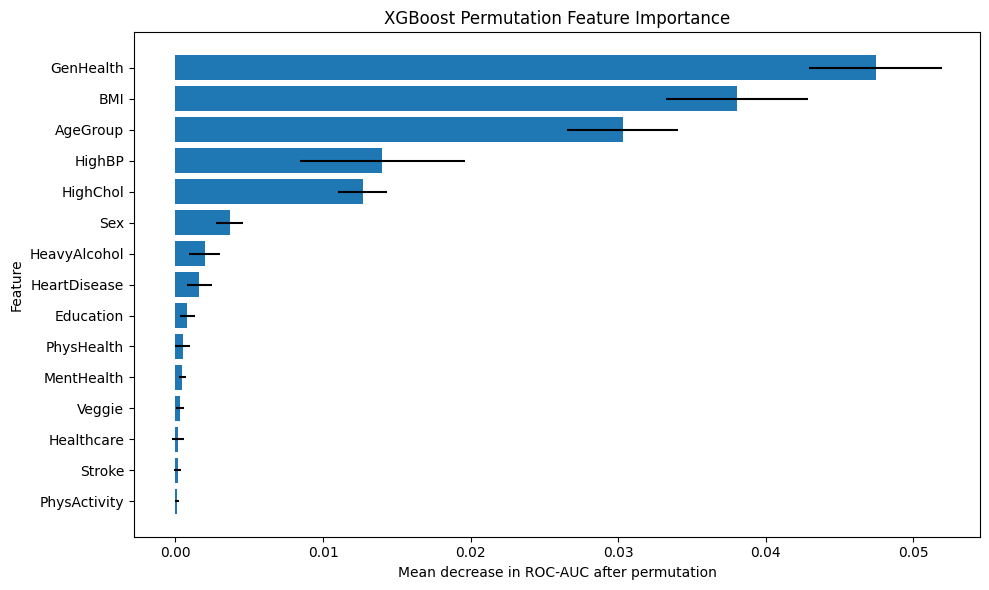

In [63]:
# ---------------------------------------------------------
# Permutation Feature Importance for XGBoost
# ---------------------------------------------------------

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Select best XGBoost model based on PR-AUC
best_xgb_name = xgb_summary.sort_values(
    by="pr_auc",
    ascending=False
).iloc[0]["model"]

best_xgb_model = xgb_fitted_models[best_xgb_name]

print("Best XGBoost model:", best_xgb_name)

# Stratified 2,000-row subsample
sample_size = min(2000, len(X_test))

X_test_sample, _, y_test_sample, _ = train_test_split(
    X_test,
    y_test,
    train_size=sample_size,
    stratify=y_test,
    random_state=RANDOM_STATE
)

# Compute permutation importance (ROC-AUC drop)
xgb_perm_result = permutation_importance(
    best_xgb_model,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Create importance DataFrame
xgb_perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": xgb_perm_result.importances_mean,
    "importance_std": xgb_perm_result.importances_std
})

xgb_perm_importance = xgb_perm_importance.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

print("Top 15 XGBoost permutation feature importances:")
print(xgb_perm_importance.head(15).to_string(index=False))

# Plot top 15 permutation feature importances for XGBoost

top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_perm_importance.head(top_n)["feature"][::-1],
    xgb_perm_importance.head(top_n)["importance_mean"][::-1],
    xerr=xgb_perm_importance.head(top_n)["importance_std"][::-1]
)

plt.xlabel("Mean decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("XGBoost Permutation Feature Importance")
plt.tight_layout()
plt.show()

# **3 Hypothesis Tests**

## Hypothesis Testing Approach

In this project, we conduct hypothesis testing to evaluate whether specific health and lifestyle variables are statistically associated with diabetes-related conditions. The target variable is defined as a binary outcome, where 0 represents no diabetes and 1 represents prediabetes or diabetes.

We formulate hypotheses for each factor of interest and apply both classical statistical tests and permutation-based methods to ensure robustness of our conclusions.

### General Framework

For each hypothesis, we follow these steps:

1. **Define Null and Alternative Hypotheses**  
   The null hypothesis ($H_0$) assumes no association between the explanatory variable and diabetes risk.  
   The alternative hypothesis ($H_1$) reflects the expected directional relationship (e.g., reduced risk or increased mean).

2. **Compute a Test Statistic**  
   We select an appropriate statistic based on the variable type:
   - For categorical variables (e.g., physical activity), we use the difference in sample proportions:
     $$
     \hat{p}_1 - \hat{p}_0
     $$
   - For continuous variables (e.g., BMI), we use the difference in sample means:
     $$
     \bar{x}_1 - \bar{x}_0
     $$

3. **Classical Hypothesis Testing**  
   - For proportion comparisons, we use a two-proportion z-test.
   - For mean comparisons, we use a two-sample Welch t-test, which does not assume equal variances.
   - P-values are computed based on the sampling distribution under the null hypothesis.

4. **Permutation Testing**  
   To complement classical methods, we perform permutation tests by randomly shuffling the diabetes labels while keeping the feature values fixed. This simulates the null hypothesis of no association.

   For each permutation:
   - Recompute the test statistic
   - Build a distribution of the statistic under the null hypothesis

   The p-value is then estimated as the proportion of permuted statistics that are as extreme as or more extreme than the observed statistic.

5. **Decision Rule**  
   We compare the p-value to a significance level (typically $\alpha = 0.05$):
   - If $p < \alpha$, we reject the null hypothesis
   - Otherwise, we fail to reject the null hypothesis

## **3.1 Hypothesis 1: Physical Activity and Diabetes**

- **H₀:** Physical activity has no association with diabetes status  

$$
P(\text{Diabetes} = 1 \mid \text{PhysActivity} = 1)
=
P(\text{Diabetes} = 1 \mid \text{PhysActivity} = 0)
$$

- **H₁:** Physical activity reduces the probability of diabetes  

$$
P(\text{Diabetes} = 1 \mid \text{PhysActivity} = 1)
<
P(\text{Diabetes} = 1 \mid \text{PhysActivity} = 0)
$$

- **Test statistic:** Difference in sample proportions  

$$
\hat{p}_1 - \hat{p}_0
$$

where:

- $\hat{p}_1$: diabetes rate among physically active individuals  
- $\hat{p}_0$: diabetes rate among inactive individuals  

### *Results*

The estimated diabetes risk among physically active individuals is 0.1325, compared to 0.2356 among inactive individuals. The observed difference in proportions is -0.1031, indicating that physically active individuals have a substantially lower risk of diabetes-related conditions.

Both the permutation test and the classical two-proportion z-test yield p-values that are effectively zero. Therefore, we reject the null hypothesis that physical activity has no association with diabetes risk.

This provides strong statistical evidence that physical activity is associated with a lower probability of diabetes-related conditions. In addition to statistical significance, the effect size is also practically meaningful, as the difference in risk is over 10 percentage points.

However, it is important to note that this analysis is based on observational data, and thus the result reflects an association rather than a causal relationship.

In [64]:
import numpy as np
from scipy import stats

# =========================================================
# Hypothesis 1:
# H0: Physical activity has no association with diabetes risk
# H1: Physically active individuals have lower diabetes risk
# =========================================================

# Keep only relevant columns and drop missing values
hyp1_df = df_binary[["Diabetes", "PhysActivity"]].dropna().copy()

# Split into two groups
active = hyp1_df[hyp1_df["PhysActivity"] == 1]["Diabetes"]
inactive = hyp1_df[hyp1_df["PhysActivity"] == 0]["Diabetes"]

# Compute proportions (since Diabetes is 0/1, mean = probability)
p_hat_1 = active.mean()
p_hat_0 = inactive.mean()

obs_diff = p_hat_1 - p_hat_0

print("=== Hypothesis 1 ===")
print(f"Risk (active)   = {p_hat_1:.4f}")
print(f"Risk (inactive) = {p_hat_0:.4f}")
print(f"Difference      = {obs_diff:.4f}")

=== Hypothesis 1 ===
Risk (active)   = 0.1325
Risk (inactive) = 0.2356
Difference      = -0.1031


In [65]:
# =========================================================
# Hypothesis 1 Permutation test
# Shuffle Diabetes labels to simulate H0
# =========================================================

n_perm = 10000
perm_diffs = np.empty(n_perm)

y = hyp1_df["Diabetes"].values
active_mask = hyp1_df["PhysActivity"].values == 1

for i in range(n_perm):
    shuffled = np.random.permutation(y)
    p1 = shuffled[active_mask].mean()
    p0 = shuffled[~active_mask].mean()
    perm_diffs[i] = p1 - p0

# One-sided (H1: active < inactive → diff < 0)
p_value_perm = np.mean(perm_diffs <= obs_diff)

print(f"Permutation p-value = {p_value_perm:.6f}")

Permutation p-value = 0.000000


In [66]:
# =========================================================
# Hypothesis 1 Classical two-proportion z-test
# =========================================================

x1 = active.sum()
n1 = len(active)

x0 = inactive.sum()
n0 = len(inactive)

p_pool = (x1 + x0) / (n1 + n0)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n0))

z_stat = (p_hat_1 - p_hat_0) / se

# One-sided test
p_value_z = stats.norm.cdf(z_stat)

print(f"Z-statistic = {z_stat:.4f}")
print(f"Z-test p-value = {p_value_z:.6f}")

Z-statistic = -61.1410
Z-test p-value = 0.000000


## **3.2 Hypothesis 2: BMI and Diabetes**

- **H₀:** Mean BMI is the same for diabetic and non-diabetic individuals  

$$
\mu_{\text{BMI, diabetic}}
=
\mu_{\text{BMI, non-diabetic}}
$$

- **H₁:** Diabetic individuals have higher BMI  

$$
\mu_{\text{BMI, diabetic}}
>
\mu_{\text{BMI, non-diabetic}}
$$

- **Test statistic:** Two-sample t-statistic  

$$
t = \frac{\bar{x}_1 - \bar{x}_0}{SE}
$$

### *Results*

The average BMI among individuals with diabetes-related conditions is 31.8172, compared to 27.7586 among those without. The observed difference in means is 4.0586, indicating that the risk group has a substantially higher BMI on average.

Both the Welch two-sample t-test and the permutation test yield p-values that are effectively zero. Therefore, we reject the null hypothesis that the mean BMI is the same for the two groups.

This provides strong statistical evidence that individuals with diabetes-related conditions tend to have higher BMI. In addition to statistical significance, the effect size is also practically meaningful, as the difference exceeds 4 BMI units.

However, since the data is observational, this result indicates an association rather than a causal relationship.

In [67]:
# =========================================================
# Hypothesis 2:
# H0: Mean BMI is the same
# H1: Higher BMI for diabetes-risk group
# =========================================================

hyp2_df = df_binary[["Diabetes", "BMI"]].dropna().copy()

bmi_1 = hyp2_df[hyp2_df["Diabetes"] == 1]["BMI"]
bmi_0 = hyp2_df[hyp2_df["Diabetes"] == 0]["BMI"]

mean_1 = bmi_1.mean()
mean_0 = bmi_0.mean()

obs_mean_diff = mean_1 - mean_0

print("\n=== Hypothesis 2 ===")
print(f"Mean BMI (risk group) = {mean_1:.4f}")
print(f"Mean BMI (no risk)    = {mean_0:.4f}")
print(f"Difference            = {obs_mean_diff:.4f}")


=== Hypothesis 2 ===
Mean BMI (risk group) = 31.8172
Mean BMI (no risk)    = 27.7586
Difference            = 4.0586


In [68]:
# =========================================================
# Permutation test for BMI difference
# =========================================================

n_perm = 10000
perm_diffs = np.empty(n_perm)

bmi_values = hyp2_df["BMI"].values
labels = hyp2_df["Diabetes"].values

for i in range(n_perm):
    shuffled = np.random.permutation(labels)
    mean1 = bmi_values[shuffled == 1].mean()
    mean0 = bmi_values[shuffled == 0].mean()
    perm_diffs[i] = mean1 - mean0

# One-sided (H1: mean1 > mean0)
p_value_perm_bmi = np.mean(perm_diffs >= obs_mean_diff)

print(f"Permutation p-value = {p_value_perm_bmi:.6f}")

Permutation p-value = 0.000000


In [69]:
# =========================================================
# Welch t-test (unequal variance)
# =========================================================

t_stat, p_two = stats.ttest_ind(
    bmi_1,
    bmi_0,
    equal_var=False,
    nan_policy="omit"
)

# Convert to one-sided
if t_stat > 0:
    p_one = p_two / 2
else:
    p_one = 1 - p_two / 2

print(f"T-statistic = {t_stat:.4f}")
print(f"T-test p-value = {p_one:.6f}")

T-statistic = 104.0201
T-test p-value = 0.000000
